In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
sns.set_theme(style='whitegrid', palette='deep')

DATA_PATH = Path('messy_ecommerce_15000_student_practice.csv')
CLEAN_PATH = Path('cleaned_ecommerce_dataset.csv')
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
display(df.head())
display(df.dtypes.rename('dtype').to_frame())
print('\nMissing values:')
display(df.isna().sum().rename('missing').to_frame())
print(f'\nExact duplicate rows: {df.duplicated().sum():,}')

Rows: 15,075 | Columns: 16


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
0,ORD106680,CUST7362,28.00,Male,Hyderabad,Fashion,Shoes,2,"2,507.76",15.00,Debit Card,2025-08-27,4.10,7.00,No,"4,263.19"
1,ORD103291,CUST3155,30.00,Female,Delhi,Fashion,Jeans,2,"1,988.04",25.00,Debit Card,2025-06-18,4.20,4.00,No,"2,982.06"
2,ORD106559,CUST1349,32.00,Male,Pune,Sports,Yoga Mat,2,776.35,15.00,UPI,2025-01-13,3.60,2.00,No,"1,319.80"
3,ORD107927,CUST6779,39.00,Female,Chennai,Electronics,Smartwatch,1,"7,739.89",10.00,UPI,2026-06-01,3.20,6.00,Yes,"6,965.90"
4,ORD105665,CUST1389,27.00,Male,Chennai,Electronics,Laptop,1,"61,138.76",5.00,Debit Card,2026-06-17,3.10,5.00,No,"58,081.82"


,dtype
Order_ID,str
Customer_ID,str
Age,float64
Gender,str
City,str
Product_Category,str
Product,str
Quantity,int64
Unit_Price,float64
Discount,float64



Missing values:


,missing
Order_ID,0
Customer_ID,0
Age,271
Gender,179
City,150
Product_Category,0
Product,0
Quantity,0
Unit_Price,0
Discount,121



Exact duplicate rows: 75


In [2]:
# Numerical and categorical summaries
numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print('Numerical columns:', numeric_cols)
display(df[numeric_cols].describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).T)

range_summary = (df[numeric_cols].max() - df[numeric_cols].min()).sort_values(ascending=False)
print('Numerical ranges, largest first:')
display(range_summary.rename('range').to_frame())

print('Categorical columns:', categorical_cols)
cat_summary = df[categorical_cols].describe().T.rename(columns={'count': 'non_missing', 'unique': 'unique_values', 'top': 'most_frequent', 'freq': 'frequency'})
display(cat_summary)

print('Observations:')
print('- Total_Amount and Unit_Price have the widest numeric ranges because products vary greatly in price.')
print('- Quantity is tightly bounded, while Discount, Rating, and Delivery_Days have small practical ranges.')
print('- Gender, Payment_Method, and Returned contain inconsistent capitalization that must be standardized before grouping.')

Numerical columns: ['Age', 'Quantity', 'Unit_Price', 'Discount', 'Rating', 'Delivery_Days', 'Total_Amount']


,count,mean,std,min,10%,25%,50%,75%,90%,max
Age,"14,804.00",32.32,9.02,5.00,20.00,26.00,32.00,38.00,44.00,99.00
Quantity,"15,075.00",1.90,1.08,1.00,1.00,1.00,2.00,2.00,4.00,5.00
Unit_Price,"15,075.00","7,409.18","13,950.01",425.61,727.81,"1,248.32","2,480.28","3,811.45","23,330.43","309,655.38"
Discount,"14,954.00",12.02,7.70,0.00,0.00,5.00,10.00,15.00,25.00,30.00
Rating,"14,694.00",3.87,0.74,1.00,2.90,3.40,3.90,4.40,4.90,5.00
Delivery_Days,"14,895.00",4.49,1.96,1.00,2.00,3.00,4.00,6.00,7.00,14.00
Total_Amount,"15,075.00","12,553.36","29,550.80",298.27,875.78,"1,742.19","3,223.75","7,739.26","34,579.06","1,238,621.52"


Numerical ranges, largest first:


,range
Total_Amount,"1,238,323.25"
Unit_Price,"309,229.77"
Age,94.00
Discount,30.00
Delivery_Days,13.00
Quantity,4.00
Rating,4.00


Categorical columns: ['Order_ID', 'Customer_ID', 'Gender', 'City', 'Product_Category', 'Product', 'Payment_Method', 'Order_Date', 'Returned']


,non_missing,unique_values,most_frequent,frequency
Order_ID,15075,15000,ORD100543,2
Customer_ID,15075,6795,CUST1345,8
Gender,14896,5,Female,7292
City,14925,12,Kolkata,1274
Product_Category,15075,6,Electronics,3815
Product,15075,30,Smartwatch,798
Payment_Method,14849,8,Credit Card,2510
Order_Date,15075,730,2026-05-29,41
Returned,15075,3,No,13229


Observations:
- Total_Amount and Unit_Price have the widest numeric ranges because products vary greatly in price.
- Quantity is tightly bounded, while Discount, Rating, and Delivery_Days have small practical ranges.
- Gender, Payment_Method, and Returned contain inconsistent capitalization that must be standardized before grouping.


In [3]:
# Unique values and categorical consistency audit
for column in ['Gender', 'City', 'Product_Category', 'Payment_Method', 'Returned']:
    print(f'\n{column} ({df[column].nunique(dropna=True)} unique values):')
    display(df[column].value_counts(dropna=False).rename('count').to_frame())

print('\nCase-insensitive duplicate category groups:')
for column in ['Gender', 'Payment_Method', 'Returned']:
    grouped = df[column].dropna().groupby(df[column].dropna().str.casefold()).unique()
    inconsistent = grouped[grouped.map(len) > 1]
    print(f'{column}: {inconsistent.to_dict()}')

print('\nMost common categories:')
for column in ['Gender', 'City', 'Product_Category', 'Payment_Method', 'Returned']:
    value = df[column].value_counts(dropna=True).idxmax()
    print(f'{column}: {value} ({df[column].value_counts(dropna=True).max():,} records)')


Gender (5 unique values):


,count
Gender,
Female,7292
Male,7023
Other,441
NaN,179
male,80
female,60



City (12 unique values):


,count
City,
Kolkata,1274
Vijayawada,1271
Ahmedabad,1268
Pune,1263
Guntur,1251
Hyderabad,1241
Bengaluru,1237
Warangal,1235
Delhi,1234



Product_Category (6 unique values):


...


Payment_Method (8 unique values):


,count
Payment_Method,
Credit Card,2510
Net Banking,2490
Wallet,2485
UPI,2450
Debit Card,2444
COD,2390
NaN,226
upi,40
credit card,40



Returned (3 unique values):


,count
Returned,
No,13229
Yes,1816
yes,30



Case-insensitive duplicate category groups:
Gender: {'female': <StringArray>
['Female', 'female']
Length: 2, dtype: str, 'male': <StringArray>
['Male', 'male']
Length: 2, dtype: str}
Payment_Method: {'credit card': <StringArray>
['Credit Card', 'credit card']
Length: 2, dtype: str, 'upi': <StringArray>
['UPI', 'upi']
Length: 2, dtype: str}
Returned: {'yes': <StringArray>
['Yes', 'yes']
Length: 2, dtype: str}

Most common categories:
Gender: Female (7,292 records)
City: Kolkata (1,274 records)
Product_Category: Electronics (3,815 records)
Payment_Method: Credit Card (2,510 records)
Returned: No (13,229 records)


In [4]:
# Clean categorical values, dates, and missing numeric values
rows_before_missing = df.shape

for column in ['Gender', 'Payment_Method', 'Returned']:
    df[column] = df[column].str.strip().str.casefold()

category_maps = {
    'Gender': {'male': 'Male', 'female': 'Female', 'other': 'Other'},
    'Payment_Method': {'cod': 'COD', 'credit card': 'Credit Card', 'debit card': 'Debit Card', 'net banking': 'Net Banking', 'upi': 'UPI', 'wallet': 'Wallet'},
    'Returned': {'yes': 'Yes', 'no': 'No'}
}
for column, mapping in category_maps.items():
    df[column] = df[column].map(mapping)

df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

numeric_fill_methods = {
    'Age': 'median',
    'Discount': 'median',
    'Rating': 'median',
    'Delivery_Days': 'median'
}
for column in numeric_fill_methods:
    df[column] = df[column].fillna(df[column].median())

for column in ['Gender', 'City', 'Payment_Method']:
    df[column] = df[column].fillna(df[column].mode()[0])

print('Missing values after treatment:')
display(df.isna().sum().rename('missing').to_frame())
print(f'Dimensions before treatment: {rows_before_missing}')
print(f'Dimensions after treatment:  {df.shape}')
print('\nMethods: numeric columns use the median to resist skew and preserve row count; categorical columns use the mode because each row needs a valid category.')

Missing values after treatment:


,missing
Order_ID,0
Customer_ID,0
Age,0
Gender,0
City,0
Product_Category,0
Product,0
Quantity,0
Unit_Price,0
Discount,0


Dimensions before treatment: (15075, 16)
Dimensions after treatment:  (15075, 16)

Methods: numeric columns use the median to resist skew and preserve row count; categorical columns use the mode because each row needs a valid category.


In [5]:
# Duplicate detection and removal
exact_duplicate_mask = df.duplicated(keep=False)
order_duplicate_mask = df['Order_ID'].duplicated(keep=False)
print(f'Exact duplicate rows: {df.duplicated().sum():,}')
print(f'Rows participating in duplicate groups: {exact_duplicate_mask.sum():,}')
print(f'Duplicate Order_ID rows: {order_duplicate_mask.sum():,}')
print('Sample duplicate records:')
display(df.loc[exact_duplicate_mask].sort_values('Order_ID').head(10))

records_before_duplicates = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Records before removing duplicates: {records_before_duplicates:,}')
print(f'Records removed: {records_before_duplicates - len(df):,}')
print(f'Records after removing duplicates: {len(df):,}')
print(f'Remaining exact duplicates: {df.duplicated().sum():,}')
print('\nThe duplicate Order_IDs are exact duplicate rows here, so removing exact duplicates avoids double-counting revenue and orders.')

Exact duplicate rows: 75
Rows participating in duplicate groups: 150
Duplicate Order_ID rows: 150
Sample duplicate records:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
34,ORD100150,CUST8539,26.00,Female,Delhi,Electronics,Headphones,2,"2,693.16",5.00,Net Banking,2026-10-07,4.40,6.00,No,"5,117.00"
14662,ORD100150,CUST8539,26.00,Female,Delhi,Electronics,Headphones,2,"2,693.16",5.00,Net Banking,2026-10-07,4.40,6.00,No,"5,117.00"
2462,ORD100170,CUST2577,18.00,Female,Bengaluru,Books,Novel,2,513.28,5.00,Credit Card,2025-01-27,3.40,6.00,Yes,975.24
138,ORD100170,CUST2577,18.00,Female,Bengaluru,Books,Novel,2,513.28,5.00,Credit Card,2025-01-27,3.40,6.00,Yes,975.24
106,ORD100252,CUST2938,37.00,Male,Delhi,Sports,Yoga Mat,2,948.74,15.00,Debit Card,2025-05-12,4.20,1.00,No,"1,612.86"
8052,ORD100252,CUST2938,37.00,Male,Delhi,Sports,Yoga Mat,2,948.74,15.00,Debit Card,2025-05-12,4.20,1.00,No,"1,612.86"
137,ORD100388,CUST3880,43.00,Female,Vijayawada,Books,Novel,1,434.72,15.00,Net Banking,2026-06-20,3.40,5.00,Yes,369.51
12049,ORD100388,CUST3880,43.00,Female,Vijayawada,Books,Novel,1,434.72,15.00,Net Banking,2026-06-20,3.40,5.00,Yes,369.51
33,ORD100543,CUST6787,28.00,Male,Chennai,Sports,Yoga Mat,1,831.70,20.00,UPI,2026-07-28,4.20,3.00,No,665.36
7943,ORD100543,CUST6787,28.00,Male,Chennai,Sports,Yoga Mat,1,831.70,20.00,UPI,2026-07-28,4.20,3.00,No,665.36


Records before removing duplicates: 15,075
Records removed: 75
Records after removing duplicates: 15,000
Remaining exact duplicates: 0

The duplicate Order_IDs are exact duplicate rows here, so removing exact duplicates avoids double-counting revenue and orders.


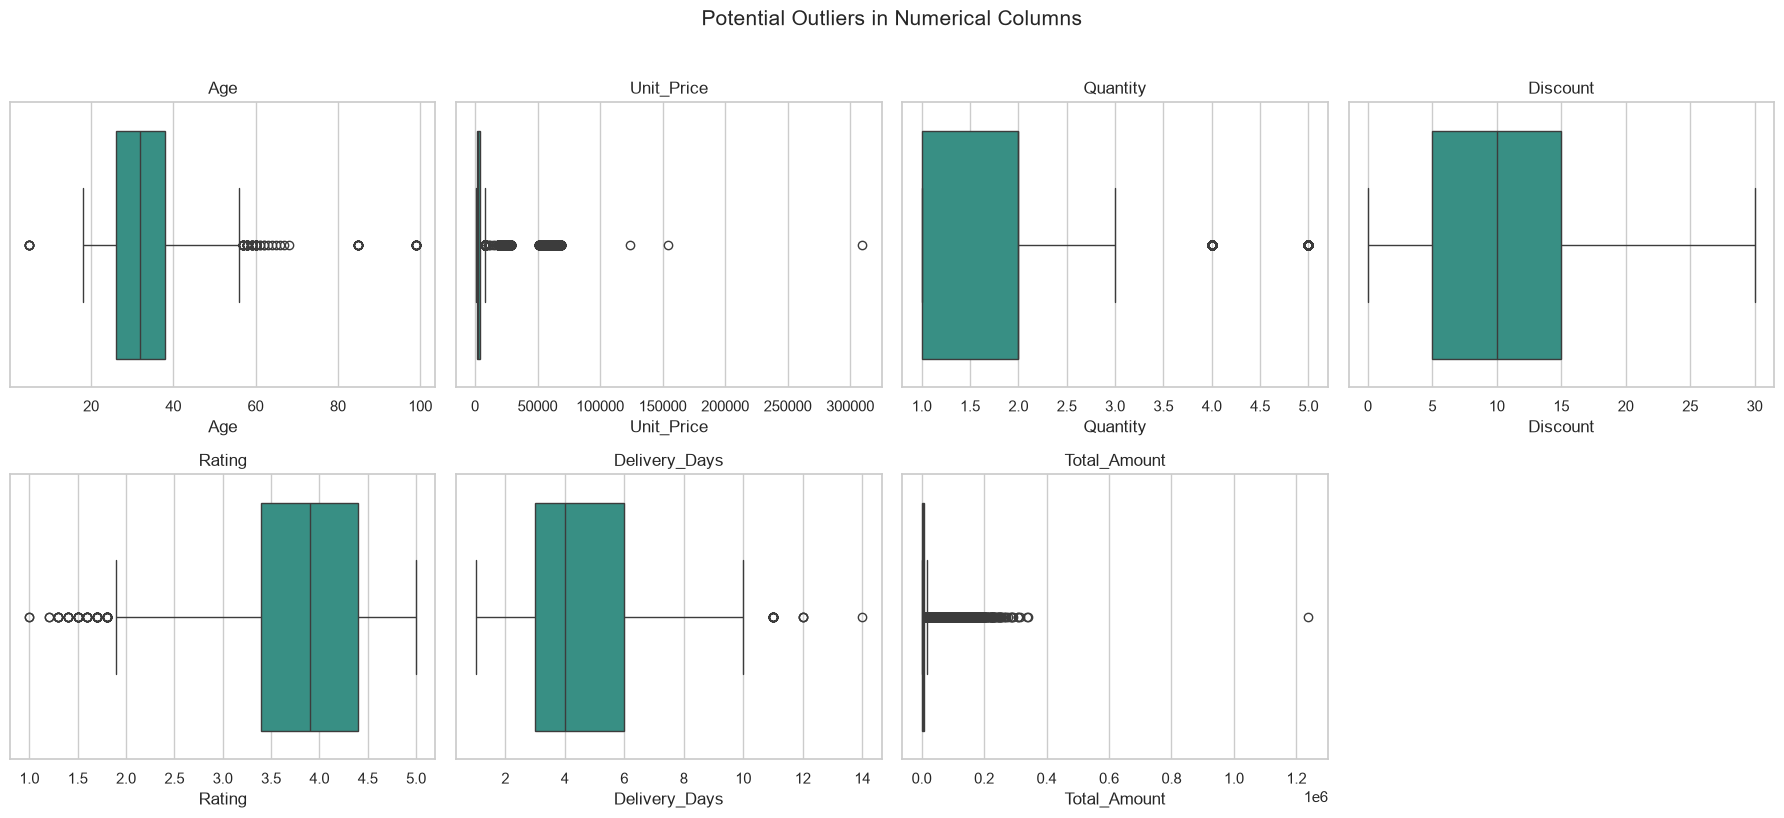

,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
column,,,,,,,
Total_Amount,"1,741.91","7,741.01","5,999.10","-7,256.74","16,739.66",2472,16.48
Unit_Price,"1,249.04","3,819.30","2,570.26","-2,606.35","7,674.68",2401,16.01
Quantity,1.00,2.00,1.00,-0.50,3.50,1513,10.09
Age,26.00,38.00,12.00,8.00,56.00,90,0.60
Rating,3.40,4.40,1.00,1.90,5.90,73,0.49
Delivery_Days,3.00,6.00,3.00,-1.50,10.50,24,0.16
Discount,5.00,15.00,10.00,-10.00,30.00,0,0.00


Decision: IQR flags are investigation candidates, not automatic errors. High Unit_Price and Total_Amount values can be legitimate premium purchases; impossible ranges would require correction, but observed core ranges are plausible.


In [6]:
# Boxplots and IQR outlier analysis
outlier_cols = ['Age', 'Unit_Price', 'Quantity', 'Discount', 'Rating', 'Delivery_Days', 'Total_Amount']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for axis, column in zip(axes.flat, outlier_cols):
    sns.boxplot(x=df[column], ax=axis, color='#2a9d8f')
    axis.set_title(column)
for axis in axes.flat[len(outlier_cols):]:
    axis.remove()
plt.suptitle('Potential Outliers in Numerical Columns', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

outlier_report = []
for column in outlier_cols:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[column] < lower) | (df[column] > upper)
    outlier_report.append({'column': column, 'Q1': q1, 'Q3': q3, 'IQR': iqr, 'lower_bound': lower, 'upper_bound': upper, 'outlier_count': int(mask.sum()), 'outlier_percent': mask.mean() * 100})
outlier_report = pd.DataFrame(outlier_report).set_index('column').sort_values('outlier_count', ascending=False)
display(outlier_report)
print('Decision: IQR flags are investigation candidates, not automatic errors. High Unit_Price and Total_Amount values can be legitimate premium purchases; impossible ranges would require correction, but observed core ranges are plausible.')

In [7]:
# Total consistency validation
# Discount is stored as a percentage, so divide by 100 in the formula.
df['Expected_Total'] = df['Unit_Price'] * df['Quantity'] * (1 - df['Discount'] / 100)
df['Amount_Difference'] = df['Total_Amount'] - df['Expected_Total']
df['Absolute_Difference'] = df['Amount_Difference'].abs()

print('Largest amount differences:')
display(df.nlargest(10, 'Absolute_Difference')[['Order_ID', 'Unit_Price', 'Quantity', 'Discount', 'Total_Amount', 'Expected_Total', 'Amount_Difference']])
print(f"Rows with difference > 1.00: {(df['Absolute_Difference'] > 1).sum():,}")
print(f"Maximum absolute difference: {df['Absolute_Difference'].max():,.2f}")
print('Most differences are rounding-level discrepancies; large differences should be investigated as possible pricing or transaction-record issues.')

Largest amount differences:


,Order_ID,Unit_Price,Quantity,Discount,Total_Amount,Expected_Total,Amount_Difference
14931,ORD109556,"51,845.68",3,10.00,"116,652.78","139,983.34","-23,330.56"
5800,ORD111725,"67,905.26",3,10.00,"203,715.77","183,344.20","20,371.57"
10398,ORD107033,"59,340.16",2,10.00,"94,944.26","106,812.29","-11,868.03"
644,ORD113636,"21,130.97",5,10.00,"105,654.87","95,089.37","10,565.50"
4781,ORD109508,"23,281.56",2,10.00,"46,563.12","41,906.81","4,656.31"
14902,ORD110174,"22,117.21",4,10.00,"84,045.39","79,621.96","4,423.43"
9999,ORD100671,"20,937.19",2,10.00,"33,499.51","37,686.94","-4,187.43"
2465,ORD110771,"8,041.91",2,10.00,"11,258.67","14,475.44","-3,216.77"
2542,ORD106416,"19,674.08",3,10.00,"50,168.89","53,120.02","-2,951.13"
10266,ORD107072,"24,851.88",2,10.00,"47,218.57","44,733.38","2,485.19"


Rows with difference > 1.00: 87
Maximum absolute difference: 23,330.56
Most differences are rounding-level discrepancies; large differences should be investigated as possible pricing or transaction-record issues.


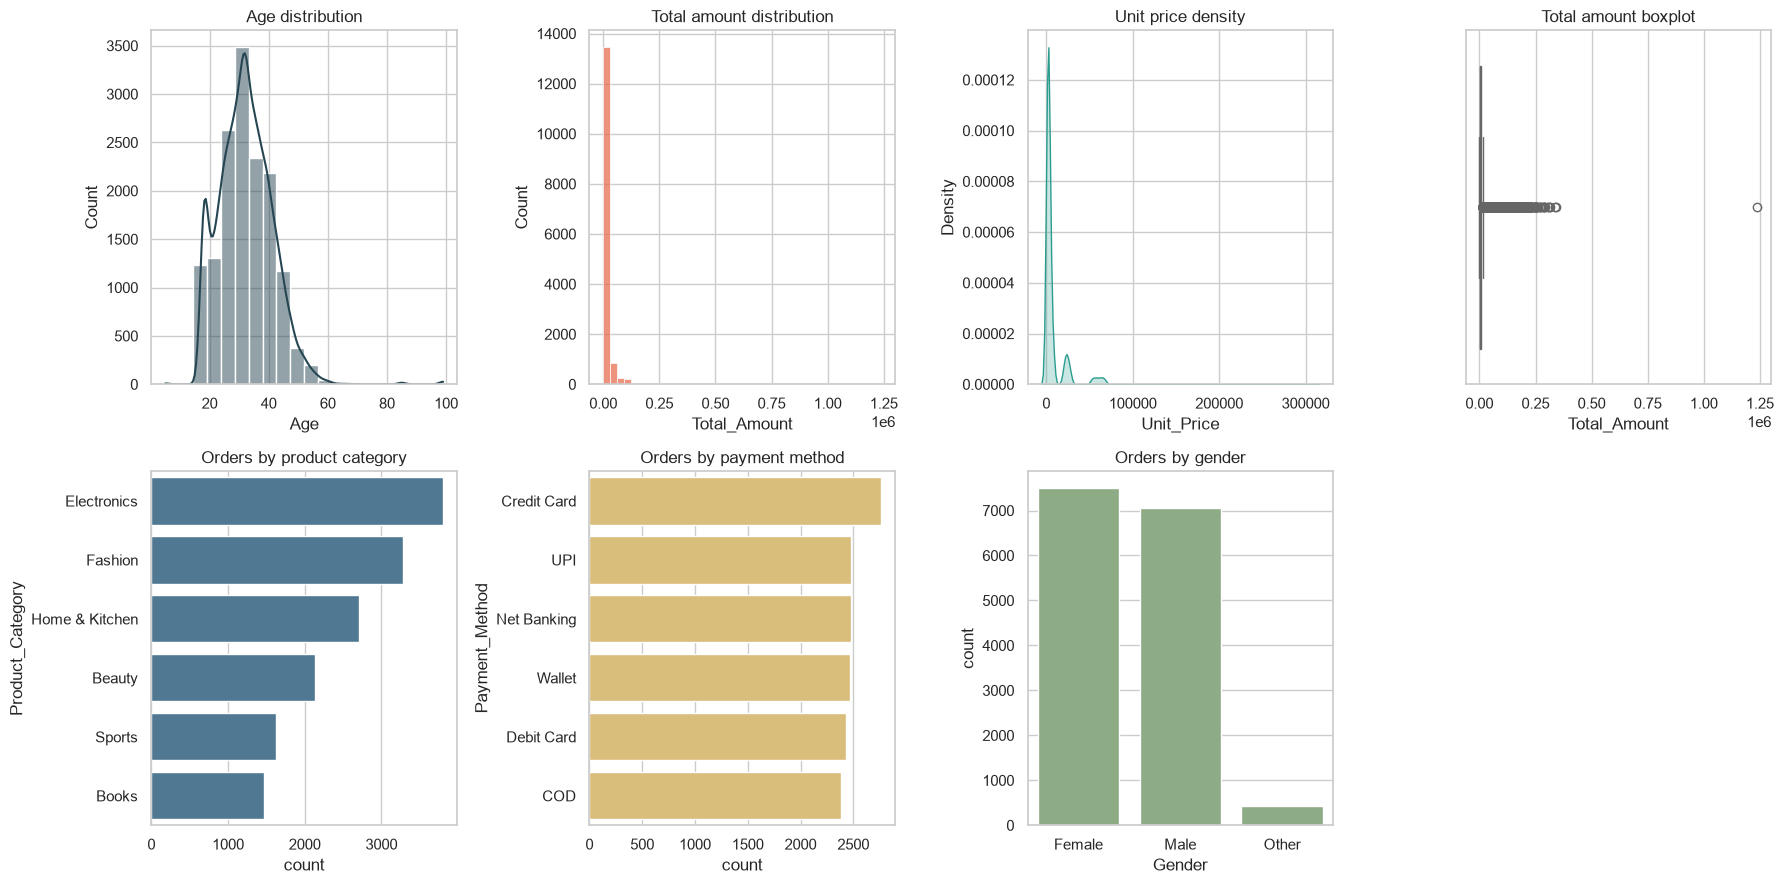

Observations: Age is concentrated around young and middle adulthood; Total_Amount and Unit_Price are right-skewed; Electronics leads category orders; Credit Card is the most common payment method; Female is the most frequent gender.


In [8]:
# Seaborn univariate analysis
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
sns.histplot(data=df, x='Age', bins=20, kde=True, ax=axes[0, 0], color='#264653')
axes[0, 0].set_title('Age distribution')
sns.histplot(data=df, x='Total_Amount', bins=40, ax=axes[0, 1], color='#e76f51')
axes[0, 1].set_title('Total amount distribution')
sns.kdeplot(data=df, x='Unit_Price', fill=True, ax=axes[0, 2], color='#2a9d8f')
axes[0, 2].set_title('Unit price density')
sns.boxplot(data=df, x='Total_Amount', ax=axes[0, 3], color='#f4a261')
axes[0, 3].set_title('Total amount boxplot')
sns.countplot(data=df, y='Product_Category', order=df['Product_Category'].value_counts().index, ax=axes[1, 0], color='#457b9d')
axes[1, 0].set_title('Orders by product category')
sns.countplot(data=df, y='Payment_Method', order=df['Payment_Method'].value_counts().index, ax=axes[1, 1], color='#e9c46a')
axes[1, 1].set_title('Orders by payment method')
sns.countplot(data=df, x='Gender', order=df['Gender'].value_counts().index, ax=axes[1, 2], color='#8ab17d')
axes[1, 2].set_title('Orders by gender')
axes[1, 3].axis('off')
plt.tight_layout()
plt.show()
print('Observations: Age is concentrated around young and middle adulthood; Total_Amount and Unit_Price are right-skewed; Electronics leads category orders; Credit Card is the most common payment method; Female is the most frequent gender.')

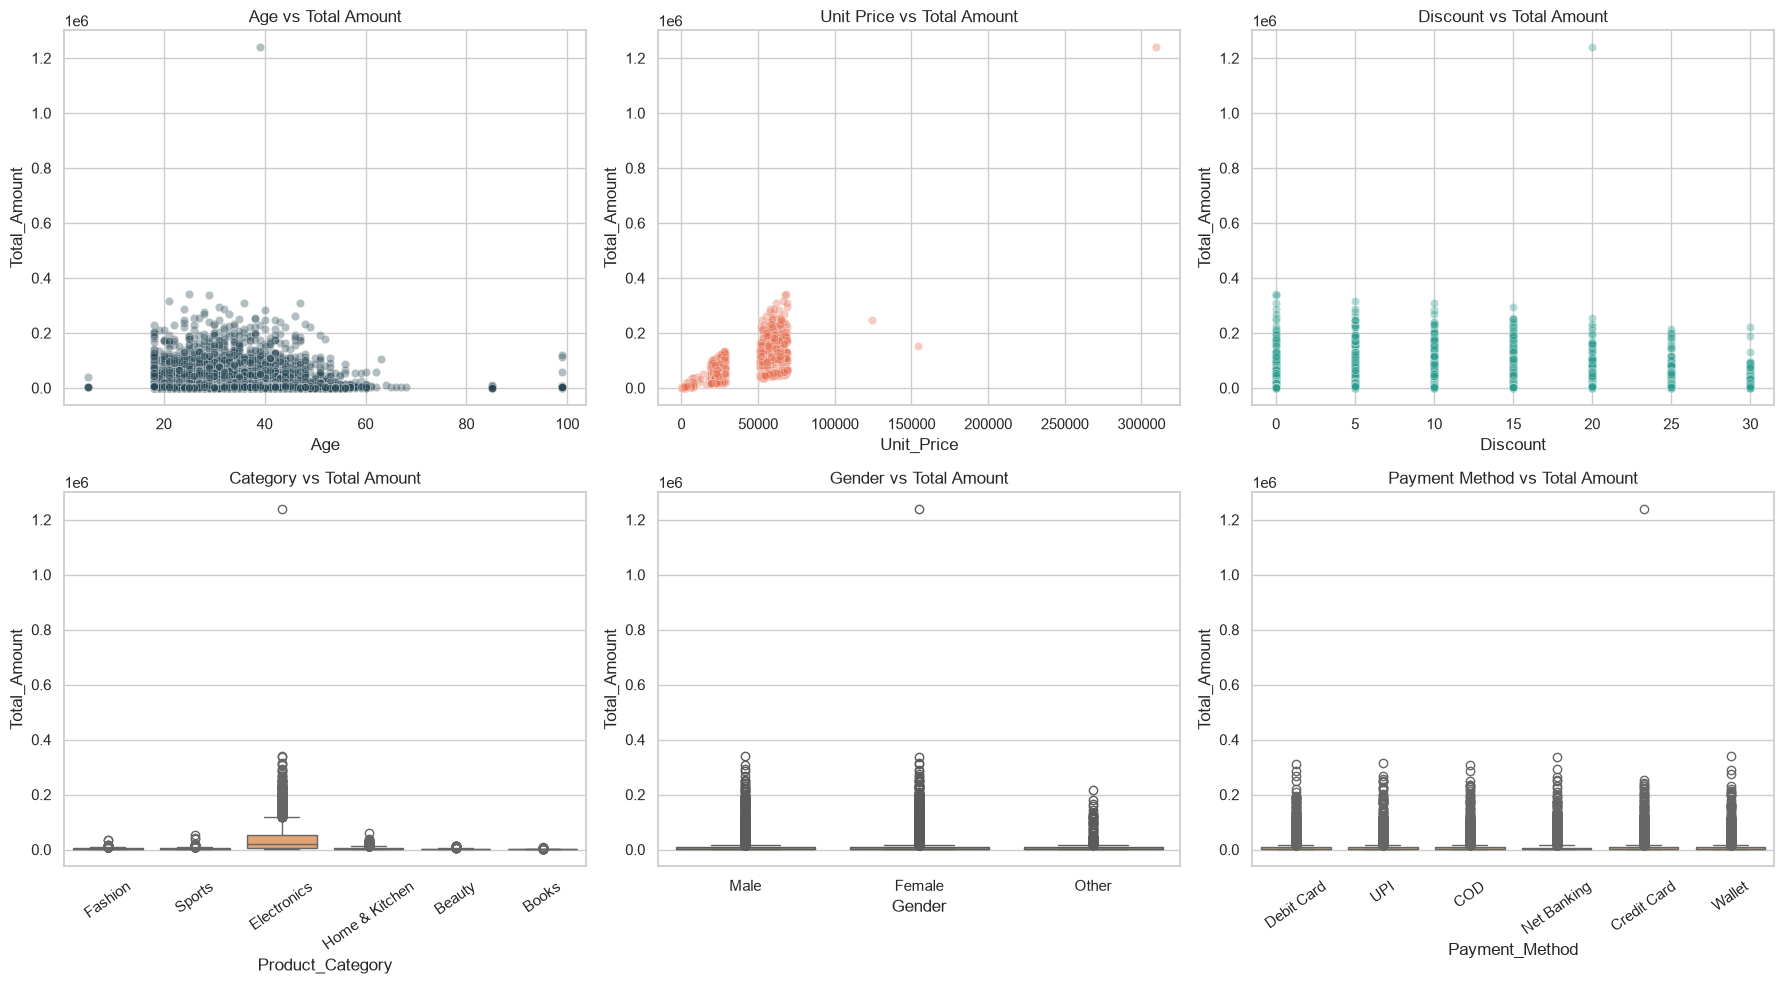

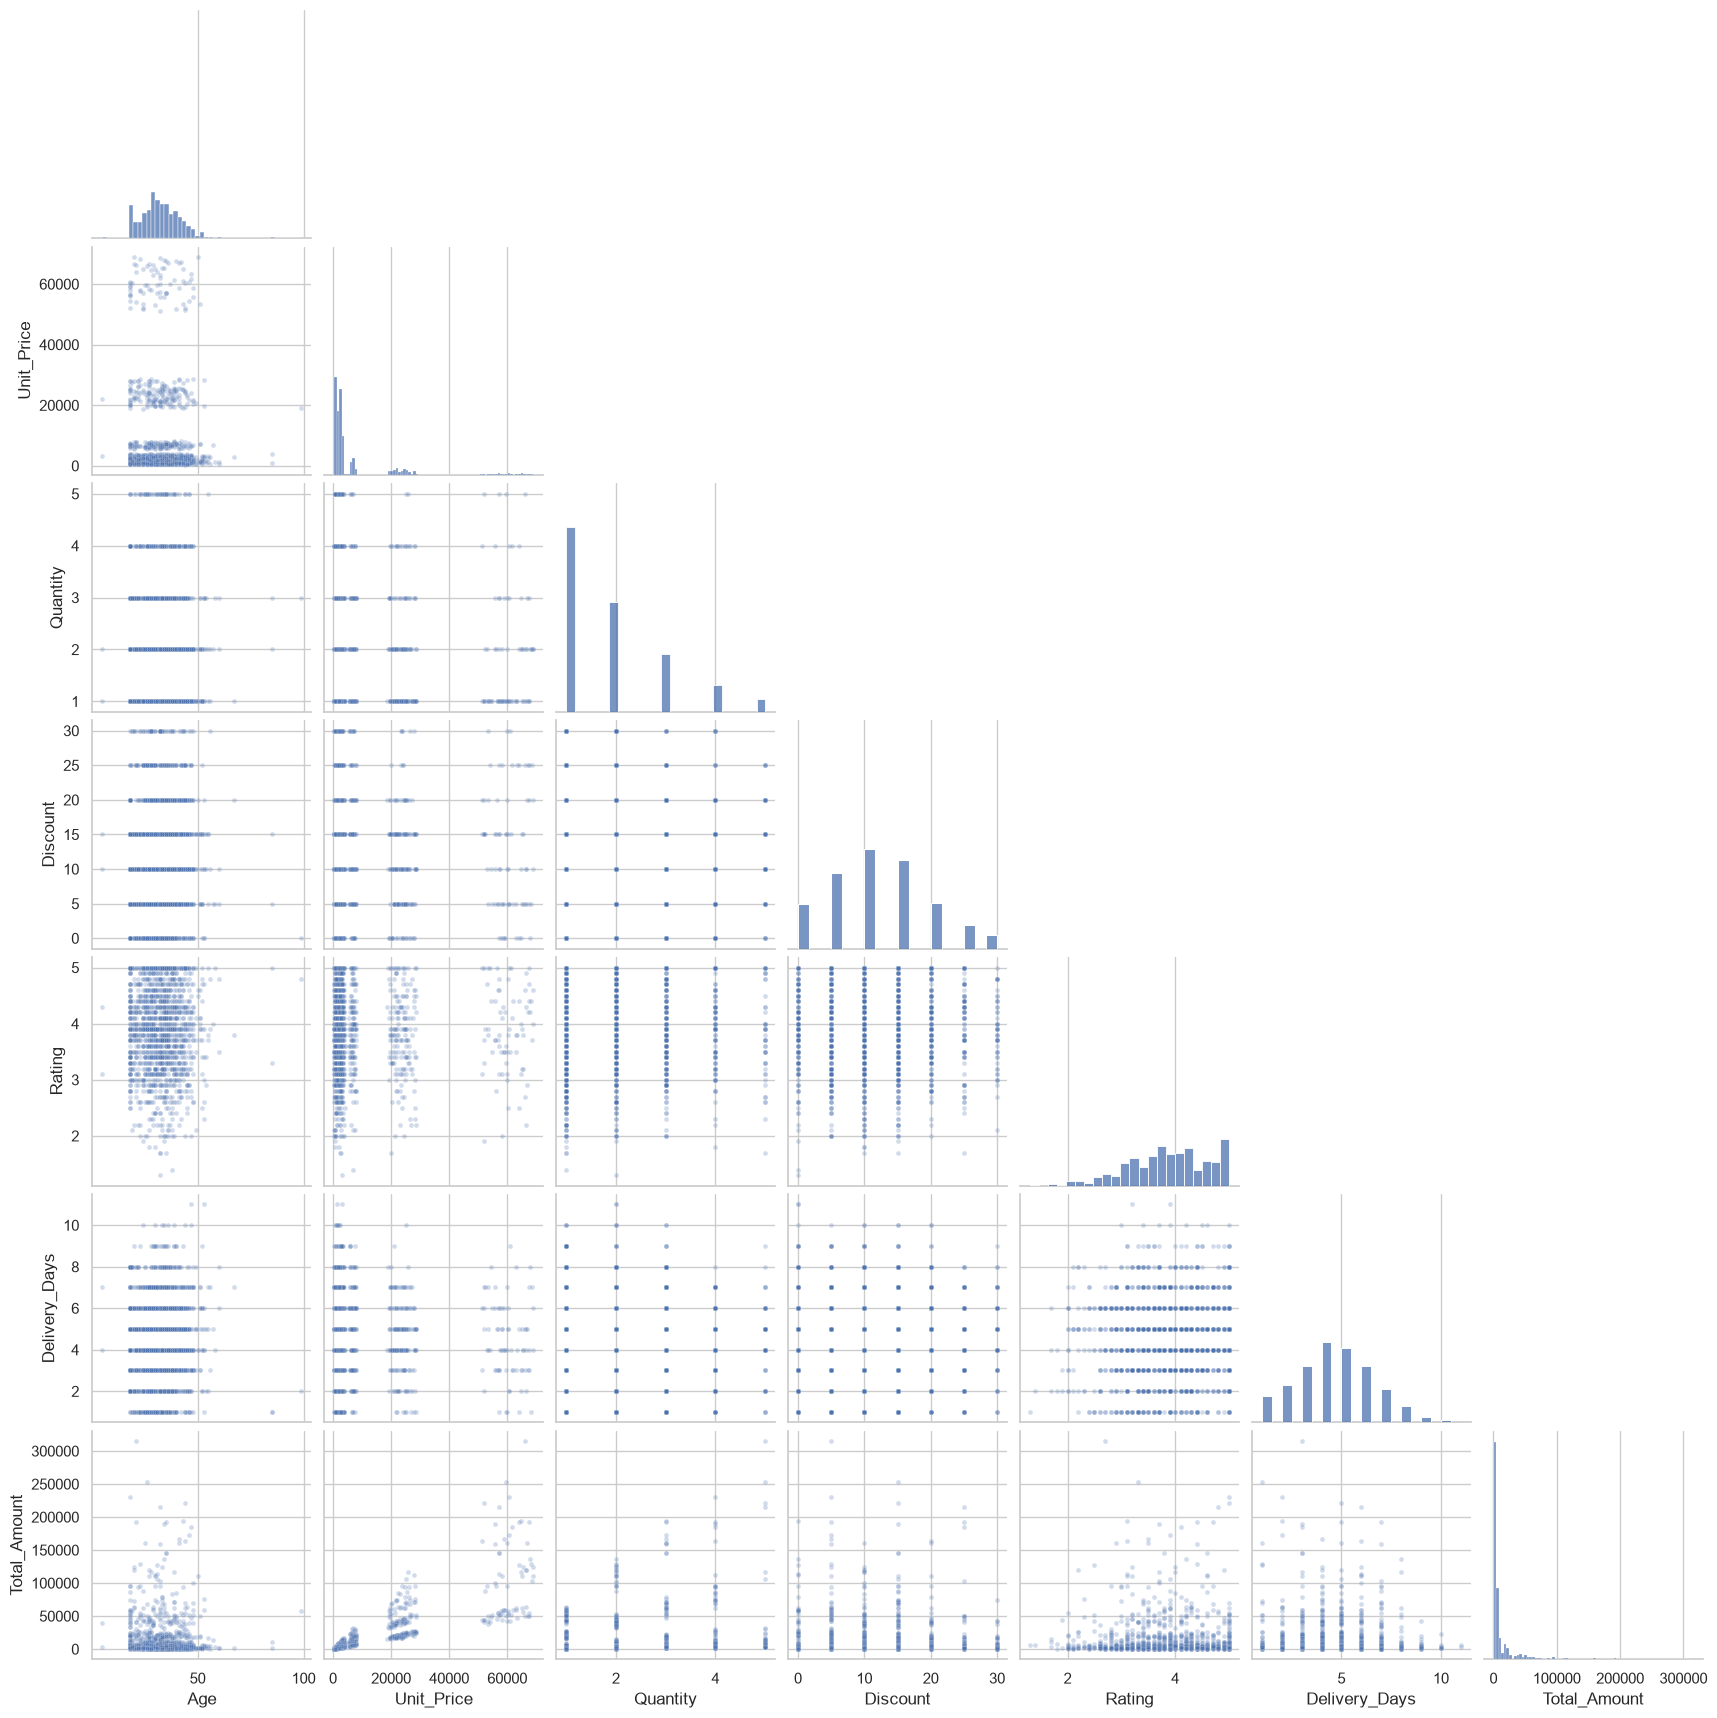

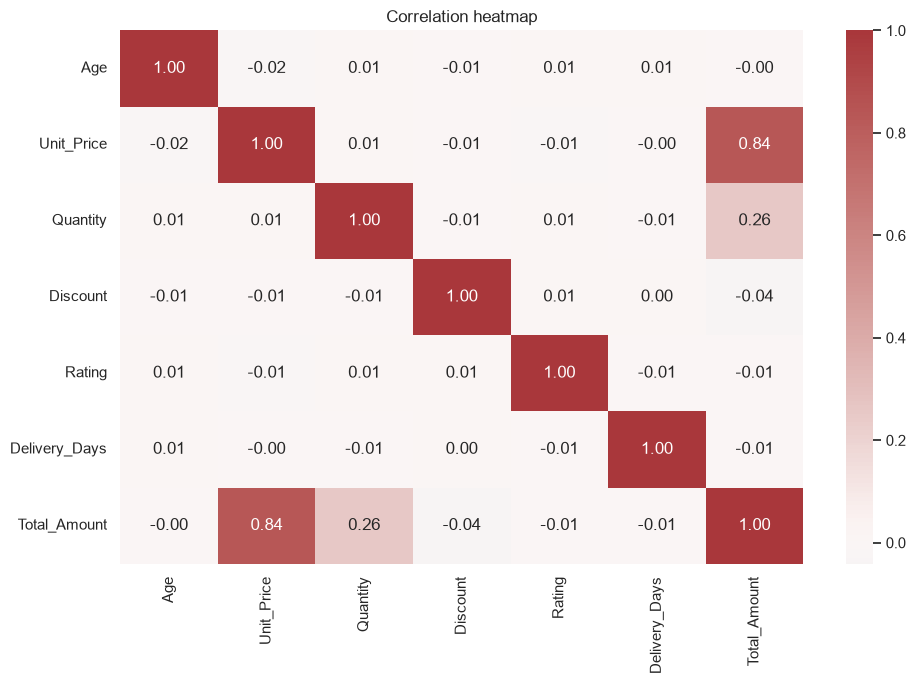

Interpretations: Unit_Price and Quantity should have the clearest positive relationships with Total_Amount because they are direct parts of the amount formula. Category and payment distributions should be compared using medians because the amount is strongly right-skewed.


In [9]:
# Seaborn bivariate and multivariate analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.scatterplot(data=df, x='Age', y='Total_Amount', alpha=0.35, ax=axes[0, 0], color='#264653')
axes[0, 0].set_title('Age vs Total Amount')
sns.scatterplot(data=df, x='Unit_Price', y='Total_Amount', alpha=0.35, ax=axes[0, 1], color='#e76f51')
axes[0, 1].set_title('Unit Price vs Total Amount')
sns.scatterplot(data=df, x='Discount', y='Total_Amount', alpha=0.35, ax=axes[0, 2], color='#2a9d8f')
axes[0, 2].set_title('Discount vs Total Amount')
sns.boxplot(data=df, x='Product_Category', y='Total_Amount', ax=axes[1, 0], color='#f4a261')
axes[1, 0].tick_params(axis='x', rotation=35)
axes[1, 0].set_title('Category vs Total Amount')
sns.boxplot(data=df, x='Gender', y='Total_Amount', ax=axes[1, 1], color='#8ab17d')
axes[1, 1].set_title('Gender vs Total Amount')
sns.boxplot(data=df, x='Payment_Method', y='Total_Amount', ax=axes[1, 2], color='#e9c46a')
axes[1, 2].tick_params(axis='x', rotation=35)
axes[1, 2].set_title('Payment Method vs Total Amount')
plt.tight_layout()
plt.show()

selected_numeric = ['Age', 'Unit_Price', 'Quantity', 'Discount', 'Rating', 'Delivery_Days', 'Total_Amount']
sns.pairplot(df[selected_numeric].sample(min(1500, len(df)), random_state=42), corner=True, plot_kws={'alpha': 0.25, 's': 12})
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df[selected_numeric].corr(), annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()
print('Interpretations: Unit_Price and Quantity should have the clearest positive relationships with Total_Amount because they are direct parts of the amount formula. Category and payment distributions should be compared using medians because the amount is strongly right-skewed.')

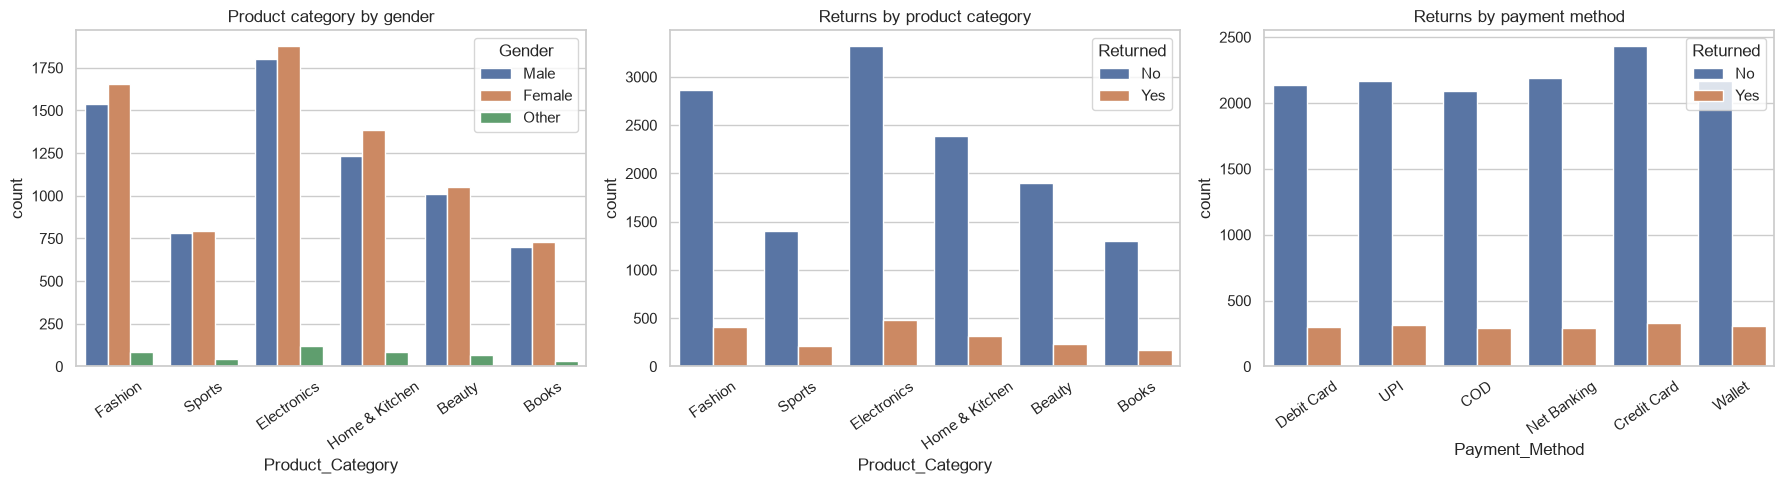

Business insights:
- Most ordered category: Electronics.
- Highest total sales category: Electronics.
- Highest average spending gender: Other.
- Highest-sales city: Kolkata.
- Return rate: 12.21%.
- Average order value by discount correlation: -0.041.


,orders,average_order_value,total_sales
Product_Category,,,
Electronics,3796,"39,440.44","149,715,896.57"
Home & Kitchen,2703,"5,126.77","13,857,669.30"
Fashion,3278,"3,444.72","11,291,786.46"
Sports,1621,"3,772.83","6,115,756.46"
Beauty,2136,"2,624.78","5,606,531.00"
Books,1466,"1,296.91","1,901,272.05"


Cleaned dataset saved to: C:\Users\HP\OneDrive\Desktop\calibo\cleaned_ecommerce_dataset.csv

Final quality check:
Dimensions: (15000, 16)
Missing cells: 0
Exact duplicate rows: 0
Duplicate Order_ID rows: 0
Order_Date dtype: datetime64[us]
Gender values: ['Female', 'Male', 'Other']
Payment methods: ['COD', 'Credit Card', 'Debit Card', 'Net Banking', 'UPI', 'Wallet']
Returned values: ['No', 'Yes']

Conclusion: The cleaned data is ready for EDA because missing values, exact duplicates, date typing, and categorical inconsistencies have been addressed. IQR flags remain documented for investigation rather than being deleted without business justification.


In [10]:
# Categorical comparisons, business insights, final checks, and export
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=df, x='Product_Category', hue='Gender', ax=axes[0])
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_title('Product category by gender')
sns.countplot(data=df, x='Product_Category', hue='Returned', ax=axes[1])
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_title('Returns by product category')
sns.countplot(data=df, x='Payment_Method', hue='Returned', ax=axes[2])
axes[2].tick_params(axis='x', rotation=35)
axes[2].set_title('Returns by payment method')
plt.tight_layout()
plt.show()

category_insights = df.groupby('Product_Category').agg(orders=('Order_ID', 'count'), average_order_value=('Total_Amount', 'mean'), total_sales=('Total_Amount', 'sum')).sort_values('total_sales', ascending=False)
city_sales = df.groupby('City')['Total_Amount'].sum().sort_values(ascending=False)
gender_spending = df.groupby('Gender')['Total_Amount'].mean().sort_values(ascending=False)
return_rate = (df['Returned'].eq('Yes').mean() * 100)
print('Business insights:')
print(f"- Most ordered category: {df['Product_Category'].value_counts().idxmax()}.")
print(f"- Highest total sales category: {category_insights.index[0]}.")
print(f"- Highest average spending gender: {gender_spending.index[0]}.")
print(f"- Highest-sales city: {city_sales.index[0]}.")
print(f'- Return rate: {return_rate:.2f}%.')
print(f"- Average order value by discount correlation: {df['Discount'].corr(df['Total_Amount']):.3f}.")
display(category_insights)

source_columns = df_raw.columns.tolist()
cleaned = df[source_columns].copy()
cleaned.to_csv(CLEAN_PATH, index=False)
print(f'Cleaned dataset saved to: {CLEAN_PATH.resolve()}')
print('\nFinal quality check:')
print(f'Dimensions: {cleaned.shape}')
print(f'Missing cells: {int(cleaned.isna().sum().sum())}')
print(f'Exact duplicate rows: {int(cleaned.duplicated().sum())}')
print(f'Duplicate Order_ID rows: {int(cleaned["Order_ID"].duplicated().sum())}')
print(f'Order_Date dtype: {cleaned["Order_Date"].dtype}')
print('Gender values:', sorted(cleaned['Gender'].unique()))
print('Payment methods:', sorted(cleaned['Payment_Method'].unique()))
print('Returned values:', sorted(cleaned['Returned'].unique()))
print('\nConclusion: The cleaned data is ready for EDA because missing values, exact duplicates, date typing, and categorical inconsistencies have been addressed. IQR flags remain documented for investigation rather than being deleted without business justification.')

In [ ]:
"""
The notebook correctly includes:

Numerical and categorical analysis
Missing-value treatment with explanations
Category standardization
Duplicate detection and removal
Boxplots and IQR outlier detection
Total amount consistency validation
Seaborn univariate, bivariate, and multivariate analysis
Correlation heatmap
Business insights
Final quality checks
Clean CSV export

"""